<a href="https://colab.research.google.com/github/Murcha1990/LLM_Course_2026/blob/main/Lection4_PEFT/01_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 1: Large Language Models

In [ ]:
%pip install bitsandbytes==0.48.2 transformers accelerate sentencepiece optimum torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.2 MB/s eta 0:00:00


In [ ]:
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import bitsandbytes as bnb
import subprocess
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm, trange
from IPython.display import clear_output
from random import sample
from tqdm import tqdm
from torchmetrics.functional import accuracy
from torch.optim import AdamW
from peft import PromptTuningConfig, PromptTuningInit, get_peft_model, LoraConfig, TaskType
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BitsAndBytesConfig

sns.set_theme()

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Для создания семинара использовались материалы ШАД и курса Александра Шабалина.

## Closed-Source модели

Сейчас все основные SoTA-решения являются Closed-Source, и доступны только через веб-интерфейс, или через API с жесткими ограничениями. Удобно, если нужно прогнать несколько вопросов - попробуйте сами.


- OpenAI API (через VPN) - [openai.com/api](https://openai.com/api/)
- Chatbot Arena (удобный способ попробовать топовые LLMки, но с очень строгими ограничениями) - [chat.lmsys.org](https://chat.lmsys.org)
- YandexGPT Lite/Pro (поддерживает дообучение) - [console.yandex.cloud](https://console.yandex.cloud/folders/b1g4lgsfdsvocob346tv/foundation-models/overview)
- GigaChat API (без дообучения) - [developers.sber.ru](https://developers.sber.ru/docs/ru/gigachat/api/overview)


Но в демо-режиме особо не разгонишься, и ничего не автоматизируешь. Для масштабного применения придется платить за доступ к API. Как быть, если хотим классные модели, но бесплатно?

## Open-Source модели

К счастью, тут спасают модели с открытым исходным кодом. Удобнее всего их искать на [HuggingFace](https://huggingface.co/models?pipeline_tag=text-generation&sort=trending) или на уже упомянутом [ChatBot Arena](https://chat.lmsys.org) - во вкладке LeaderBoard искать модели с открытыми лицензиями. Примеры:

- [ruGPT-3.5](https://huggingface.co/ai-forever/ruGPT-3.5-13B)
- [GigaChat-20B-A3B-instruct](https://huggingface.co/ai-sage/GigaChat-20B-A3B-instruct)
- [Meta-Llama-3-8B](https://huggingface.co/meta-llama/Meta-Llama-3-8B) (требует HF token)
- [Mistral-7B-Instruct](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2) (требует HF token)

Будем работать со следующими моделями:

-   [Qwen2.5-7B](https://huggingface.co/Qwen/Qwen2.5-7B)
-   [OpenChat-3.5](https://huggingface.co/openchat/openchat-3.5-0106)
-   [gpt2](https://huggingface.co/openai-community/gpt2)



### Загрузка модели

Давайте попробуем подгрузить и использовать такую модель. Сразу предупреждаю - мы будем мучать GPU, беспощадно. Не забудьте поставить GPU в среде выполнения.

In [ ]:
!nvidia-smi

Thu Jan 29 09:02:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
model_name = 'openchat/openchat-3.5-0106'

tokenizer = transformers.LlamaTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    offload_state_dict=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/179 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Можем заметить, что мы уже заняли 13 ГБ из доступных 15. Далее действовать нужно очень осторожно.

In [ ]:
!nvidia-smi

Thu Jan 29 09:11:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             29W /   70W |   12854MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Генерация

Вспомним, что под капотом это все еще просто генеративная модель, которая предсказывает вероятности следующих токенов. Что делать с этими вероятностями дальше - можно определить с помощью стратегии генерации.

| Стратегия | Описание | Плюсы и минусы |
| --- | --- | --- |
| Greedy Search | Выбирает слово с наивысшей вероятностью как следующее слово в последовательности. | Плюсы: Простота и скорость.<br> Минусы: Может привести к повторяющемуся и несвязному тексту. |
| Семплинг с температурой | Добавляет случайность в выбор слова. Большая температура приводит к большей случайности. | Плюсы: Позволяет исследовать и получать разнообразный результат.<br> Минусы: Высокие температуры могут привести к бессмысленным результатам. |
| Семплинг по ядру (Top-p семплинг) | Выбирает следующее слово из усеченного словаря, "ядра" слов, которые имеют суммарную вероятность, превышающую предустановленный порог (p). | Плюсы: Обеспечивает баланс между разнообразием и качеством.<br> Минусы: Настройка оптимального 'p' может быть затруднительна. |
| Beam Search | Исследует множество гипотез (последовательностей слов) на каждом шаге и сохраняет 'k' наиболее вероятных, где 'k' - ширина луча. | Плюсы: Дает более надежные результаты, чем жадный поиск.<br> Минусы: Может страдать от нехватки разнообразия и приводить к общим ответам. |
| Top-k семплинг | Случайным образом выбирает следующее слово из 'k' слов с самыми высокими вероятностями. | Плюсы: Вводит случайность, увеличивая разнообразие результатов.<br> Минусы: Случайный выбор иногда может привести к менее связному тексту. |
| Нормализация длины | Предотвращает предпочтение модели более коротких последовательностей за счет деления логарифмированных вероятностей на длину последовательности, возведенную в некоторую степень. | Плюсы: Делает более длинные и потенциально более информативные последовательности более вероятными.<br> Минусы: Настройка фактора нормализации может быть сложной. |
| Стохастический Beam Search | Вводит случайность в процесс выбора 'k' гипотез в поиске пучком. | Плюсы: Увеличивает разнообразие в сгенерированном тексте.<br> Минусы: Баланс между разнообразием и качеством может быть сложно управлять. |
| Декодирование с минимальным риском Байеса (MBR) | Выбирает гипотезу (из многих), которая минимизирует ожидаемую потерю для функции потерь. | Плюсы: Оптимизирует результат в соответствии с определенной функцией потерь.<br> Минусы: Вычислительно более сложно и требует хорошо подобранную функциию потерь. |

Референсы:
- [Документация `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [Документация `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- [Статья о стратегиях генерации на Huggingface](https://huggingface.co/docs/transformers/generation_strategies)

In [ ]:
prompt = 'The first discovered martian lifeform looks like'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
print("Input batch (encoded):", batch)

Input batch (encoded): {'input_ids': tensor([[    1,   415,   907,  8324, 15370,   753,  1411,   674,  4674,   737]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}


Greedy Search

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=False)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>The first discovered martian lifeform looks like a tiny, translucent, and gelatinous blob.

The discovery of the first lifeform on Mars has been announced by a team of scientists from the University of Edinburgh. The researchers have found evidence of a microscopic organism that lived on the Red Planet around 3.7 billion years


Семплинг с температурой

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=True, temperature=20.)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>The first discovered martian lifeform looks like a shades/spherules combination much associated in prestellence cosmaethiologus beliefs. Though not of planet xylograssist nature -a rather large land/tree composition associated heavily- those life/energy creatures that had lived long had a very, *hunrhyw*-*


Top-K семплинг

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=True, temperature=0.1, top_k=10)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>The first discovered martian lifeform looks like a cross between a jellyfish and a squid.

The discovery was made by a team of scientists from the University of Buckingham, who used a telescope to observe the planet.

The team, led by Dr. John Bridges, found the creature while examining images of the planet taken


Beam Search

In [ ]:
output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=False, num_beams=3)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>The first discovered martian lifeform looks like a cross between an earthworm and a caterpillar.

The discovery was made by a team of scientists from the University of California, Berkeley, who were studying images taken by NASA's Mars rover, Curiosity.

The researchers identified the creature in a rock sample that Curios


### Создание промпта

Изначально модели заточены на генерацию - чтобы общаться с ними в привычном режиме диалога промпт нужно отформатировать. Правильный формат обычно указан в документации модели, но для некоторых моделей его можно восстановить с помощью метода apply_chat_template

In [ ]:
messages = [
    {"role": "user", "content": "What is your favourite condiment?"},
    {"role": "assistant", "content": "Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!"},
    {"role": "user", "content": "Do you have mayonnaise recipes?"}
]

In [ ]:
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [ ]:
prompt

"<s>GPT4 Correct User: What is your favourite condiment?<|end_of_turn|>GPT4 Correct Assistant: Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!<|end_of_turn|>GPT4 Correct User: Do you have mayonnaise recipes?<|end_of_turn|>GPT4 Correct Assistant:"

In [ ]:
inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(device)
output_tokens = model.generate(inputs, do_sample=True, temperature=0.7, max_new_tokens=256)
print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>GPT4 Correct User: What is your favourite condiment? <|end_of_turn|> GPT4 Correct Assistant: Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen! <|end_of_turn|> GPT4 Correct User: Do you have mayonnaise recipes? <|end_of_turn|> GPT4 Correct Assistant: Certainly! Here's a simple recipe for homemade mayonnaise:

Ingredients:
- 2 large egg yolks, at room temperature
- 1 tablespoon dijon mustard
- 1 tablespoon white wine vinegar
- 1 teaspoon salt
- 1/2 teaspoon ground black pepper
- 1 1/2 cups vegetable oil or light olive oil
- Optional: 1 tablespoon fresh lemon juice

Instructions:
1. In a medium mixing bowl, whisk together the egg yolks, mustard, vinegar, salt, and pepper until well combined. This is your base mixture.
2. Begin to add the oil very slowly, drop by drop, while continually whisking the base mixture. Once the mixture starts to thicken, you can gradually increase 

У OpenChat есть два варианта ассистента - дефолтный, который реализуется с помощью apply_chat_template, и математический - для его использования нужно использовать имена Math Correct User и Math Correct Assistant.

In [ ]:
messages = [
    {"role": "user", "content": "10.3 − 7988.8133="}
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True).replace('GPT4', 'Math')

print(prompt)

<s>Math Correct User: 10.3 − 7988.8133=<|end_of_turn|>Math Correct Assistant:


In [ ]:
inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(device)
output_tokens = model.generate(inputs, do_sample=True, temperature=0.7, max_new_tokens=256)
print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>GPT4 Correct User: 10.3 − 7988.8133= <|end_of_turn|> GPT4 Correct Assistant: To subtract the second number from the first, you can do the following calculation:

10.3 - 7988.8133 = -7988.5133 <|end_of_turn|>


In [ ]:
10.3 - 7988.8133

-7978.5133

### Chain-of-Thought Reasoning

Для оптимальных промптов модели необходимо давать не только примеры ответов, но и снабжать эти примеры детально описанным процессом того, как прийти к этому результату - и при генерации требовать от модели того же.

In [ ]:
prompt = """
GPT4 Correct User:
Question: The original retail price of an appliance was 60 percent more than its wholesale cost. If the appliance was actually sold for 20 percent less than the original retail price, then it was sold for what percent more than its wholesale cost?
Answer Choices: (A) 20% (B) 28% (C) 36% (D) 40% (E) 42% <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: wholesale cost = 100;\noriginal price = 100*1.6 = 160;\nactual price = 160*0.8 = 128.\nAnswer: B.
Correct Answer: B <|end_of_turn|>


GPT4 Correct User:
Question: A grocer makes a 25% profit on the selling price for each bag of flour it sells. If he sells each bag for $100 and makes $3,000 in profit, how many bags did he sell?
Answer Choices: (A) 12 (B) 16 (C) 24 (D) 30 (E) 40 <|end_of_turn|>
GPT4 Correct Assistant:
Rationale: Profit on one bag: 100*1.25= 125\nNumber of bags sold = 3000/125 = 24\nAnswer is C.
Correct Answer: C <|end_of_turn|>


GPT4 Correct User:
Question: 20 marbles were pulled out of a bag of only white marbles, painted black, and then put back in. Then, another 20 marbles were pulled out, of which 1 was black, after which they were all returned to the bag. If the percentage of black marbles pulled out the second time represents their percentage in the bag, how many marbles in total Q does the bag currently hold?
Answer Choices: (A) 40 (B) 200 (C) 380 (D) 400 (E) 3200
GPT4 Correct Assistant:
Rationale: We know that there are 20 black marbles in the bag and this number represent 1/20 th of the number of all marbles in the bag, thus there are total Q of 20*20=400 marbles.\nAnswer: D.
Correct Answer: D <|end_of_turn|>


GPT4 Correct User: Question: Janice bikes at 10 miles per hour, while Jennie bikes at 20. How long until they have collectively biked 1 mile?
Answer Choices: (A) 1 minute (B) 2 minutes (C) 3 minutes (D) 4 minutes (E) 5 minutes
GPT4 Correct Assistant:
Rationale:
""".strip()

In [ ]:
inputs =  tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
output_tokens = model.generate(**inputs, do_sample=True, temperature=0.9, max_new_tokens=512)
print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))


Output: <s>GPT4 Correct User:
Question: The original retail price of an appliance was 60 percent more than its wholesale cost. If the appliance was actually sold for 20 percent less than the original retail price, then it was sold for what percent more than its wholesale cost?
Answer Choices: (A) 20% (B) 28% (C) 36% (D) 40% (E) 42%  <|end_of_turn|> 
GPT4 Correct Assistant:
Rationale: wholesale cost = 100;
original price = 100*1.6 = 160;
actual price = 160*0.8 = 128.
Answer: B.
Correct Answer: B  <|end_of_turn|> 


GPT4 Correct User:
Question: A grocer makes a 25% profit on the selling price for each bag of flour it sells. If he sells each bag for $100 and makes $3,000 in profit, how many bags did he sell?
Answer Choices: (A) 12 (B) 16 (C) 24 (D) 30 (E) 40  <|end_of_turn|> 
GPT4 Correct Assistant:
Rationale: Profit on one bag: 100*1.25= 125
Number of bags sold = 3000/125 = 24
Answer is C.
Correct Answer: C  <|end_of_turn|> 


GPT4 Correct User:
Question: 20 marbles were pulled out of a

In [ ]:
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

167

In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

## Использование квантизированных моделей

Если мы жестко ограничены в ресурсах, в частности, в памяти (как в колабе), бывает полезно использовать квантизированную модель. Например, мы работаем с моделью Qwen2.5-7B, но хотим уменьшить объём занимаемой оперативной памяти — тогда можем квантизировать её до 8 бит и использовать в таком виде.

In [ ]:
!nvidia-smi

Thu Jan 29 07:06:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             33W /   70W |     154MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
model_name = 'Qwen/Qwen2.5-7B'

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.,
)

model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16, # по умолчанию float32 -> float16 -> int8
    low_cpu_mem_usage=True,
    offload_state_dict=True,
    quantization_config=quantization_config,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [ ]:
prompt = 'The first discovered martian lifeform looks like'
batch = tokenizer(prompt, return_tensors='pt', return_token_type_ids=False).to(device)
print("Input batch (encoded):", batch)

output_tokens = model.generate(**batch, max_new_tokens=64, do_sample=False)

print("\nOutput:", tokenizer.decode(output_tokens[0].cpu()))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Input batch (encoded): {'input_ids': tensor([[  785,  1156, 11105, 48195,  1103,  2272,   627,  5868,  1075]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

Output: The first discovered martian lifeform looks like a tiny, red, jellyfish. It is a single cell, but it has a complex structure. It has a nucleus, and it has a cell wall. It has a tail that it uses to swim. It has a mouth, and it has tentacles. It has a digestive system. It has a nervous


In [ ]:
!nvidia-smi

Thu Jan 29 07:20:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             40W /   70W |    8980MiB /  15360MiB |     39%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Parameter-Efficient Finetuning

Теперь попробуем дообучить модель GPT2-small на задачу анализа тональности с помощью различных методов PEFT:

- LoRa – Low-Rank Adaptation
- Prompt tuning
- PEFT + LP-FT

In [ ]:
train_dataset = load_dataset("glue", "sst2", split='train[:50000]')
valid_dataset = load_dataset("glue", "sst2", split="validation")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
train_dataset[2]

{'sentence': 'that loves its characters and communicates something rather beautiful about human nature ',
 'label': 1,
 'idx': 2}

### Инициализация токенизатора и модели

In [ ]:
model_checkpoint = "gpt2"

In [ ]:
# Initializing the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

1

In [ ]:
class Model(nn.Module):
    def __init__(self, tokenizer, num_classes=2):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_classes)
        self.model.resize_token_embeddings(len(tokenizer))
        self.config = self.model.config

    def forward(self, input_ids=None, attention_mask=None, inputs_embeds=None, *args, **kwargs):
        out = self.model.transformer(
            input_ids=input_ids, inputs_embeds=inputs_embeds, attention_mask=attention_mask
        ).last_hidden_state
        lens = attention_mask.sum(-1).cpu() - 1
        out = out[torch.arange(len(lens)), lens.to(torch.long)]
        return self.model.score(out)

    @property
    def device(self):
        return next(self.model.parameters()).device


num_classes = 2
model = Model(tokenizer, num_classes)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [ ]:
sum(p.numel() for p in model.parameters())

124442112

### Проверка токенизатора

In [ ]:
tokenizer(train_dataset[0]["sentence"])

{'input_ids': [24717, 649, 3200, 507, 422, 262, 21694, 4991, 220], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
batch_size = 128
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, num_workers=2)
valid_loader = DataLoader(valid_dataset, shuffle=False, batch_size=batch_size, num_workers=2)

In [ ]:
print("       0       1")
classes = [t["label"] for t in train_dataset]
print(f"Train: {1 - np.mean(classes):0.3f} {np.mean(classes):0.3f}")

classes = [t["label"] for t in valid_dataset]
print(f"Valid: {1 - np.mean(classes):0.3f} {np.mean(classes):0.3f}")

       0       1
Train: 0.442 0.558
Valid: 0.491 0.509


### Объявление функции для обучения моделей

In [ ]:
_ = model.to(device)

In [ ]:
def training_loop_fn(model, opt, total_num_iters, eval_freq, train_loader, valid_loader):
    train_loss_history, eval_loss_history = [], []
    train_acc_history, eval_acc_history = [], []
    global_step = 0

    criterion = torch.nn.CrossEntropyLoss()
    model.train()
    while True:
        for batch in tqdm(train_loader):
            tokenized = tokenizer(batch["sentence"], padding=True, return_tensors='pt')
            for k, v in tokenized.items():
                tokenized[k] = v.to(device)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(tokenized['input_ids'], tokenized['attention_mask'], return_dict=False)
            targets = batch["label"].to(device)
            loss = criterion(logits, targets)

            opt.zero_grad()
            loss.backward()
            opt.step()

            preds = torch.nn.functional.softmax(logits, dim=-1)[:, 1]
            acc = accuracy(preds, targets, task="binary")

            train_loss_history.append((global_step, loss.item()))
            train_acc_history.append((global_step, acc.item()))

            if global_step % eval_freq == 0:
                val_loss, val_acc = evaluate(model, valid_loader)
                eval_loss_history.append((global_step, val_loss))
                eval_acc_history.append((global_step, val_acc))

                model.train()

            if global_step % 250 == 0:
                clear_output(True)

                plt.figure(figsize=(15, 5))

                plt.subplot(121)
                plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
                if len(eval_loss_history):
                    plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
                plt.legend()

                plt.subplot(122)
                plt.plot(*zip(*train_acc_history), alpha=0.5, label='train_acc')
                if len(eval_acc_history):
                    plt.plot(*zip(*eval_acc_history), color='red', label='eval_acc')
                plt.legend()
                plt.show()

            global_step += 1
            if global_step > total_num_iters:
                break
        else:
            continue
        break


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    loss_epoch = 0.
    num_epoch = 0.
    preds_list = []
    targets_list = []

    for eval_batch in dataloader:
        tokenized = tokenizer(eval_batch["sentence"], padding=True, return_tensors='pt')
        for k, v in tokenized.items():
            tokenized[k] = v.to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(tokenized['input_ids'], tokenized['attention_mask'], return_dict=False)

        loss = criterion(logits, eval_batch["label"].to(device))
        num = logits.shape[0]

        loss_epoch += loss.item() * num
        num_epoch += num
        preds = torch.nn.functional.softmax(logits, dim=-1)[:, 1]

        targets_list += eval_batch["label"].tolist()
        preds_list += preds.tolist()

    acc = accuracy(torch.tensor(preds_list).to(device), torch.tensor(targets_list).to(device), task='binary')

    return loss_epoch / num_epoch, acc.item()

### Fine-tuning

Обучаем все веса модели. Данный подход будет наиболее требовательным к памяти, однако он применяется чаще всего.

In [ ]:
model = Model(tokenizer, num_classes).to(device)
optimizer = AdamW(model.parameters(), lr=2e-6)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


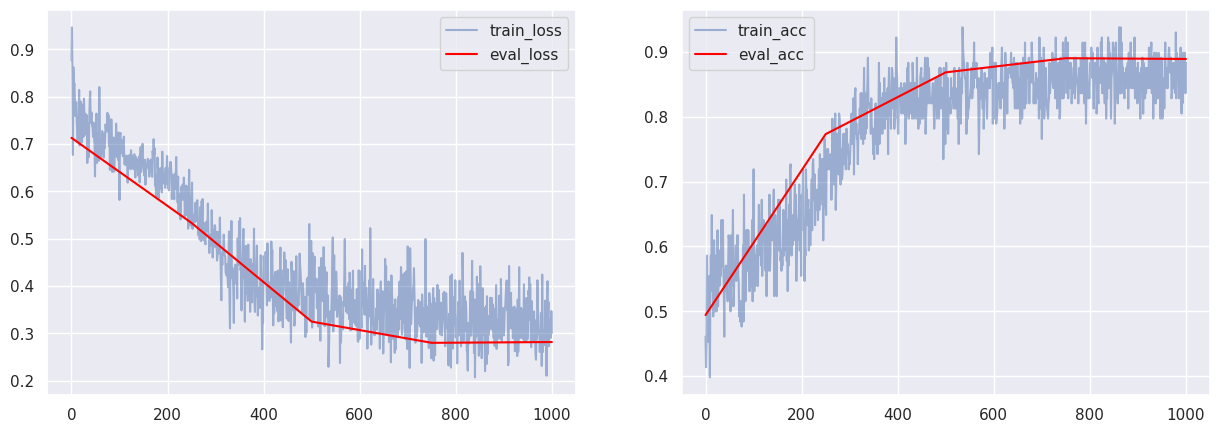

 56%|█████▌    | 218/391 [01:33<01:14,  2.33it/s]

CPU times: user 6min 58s, sys: 3.06 s, total: 7min 1s
Wall time: 7min 8s


In [ ]:
%%time
training_loop_fn(model, optimizer, 1000, 250, train_loader, valid_loader)

In [ ]:
val_loss, val_acc = evaluate(model, valid_loader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')

val loss: 0.281906267918578
val accuracy: 0.8887614607810974


In [ ]:
model.cuda()

### Linear Probing

Учим только последний линейный слой (голову) модели.

In [ ]:
model = Model(tokenizer, num_classes).to(device)
optimizer = AdamW(model.model.score.parameters(), lr=1e-4)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


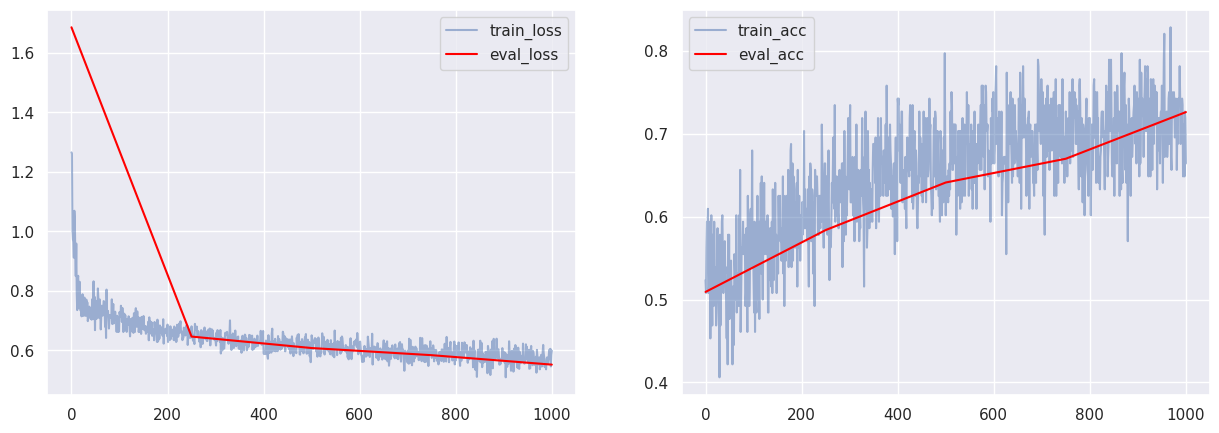

 56%|█████▌    | 218/391 [01:26<01:08,  2.53it/s]

CPU times: user 6min 24s, sys: 3.45 s, total: 6min 28s
Wall time: 6min 34s


In [ ]:
%%time
training_loop_fn(model, optimizer, 1000, 250, train_loader, valid_loader)

In [ ]:
val_loss, val_acc = evaluate(model, valid_loader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')

val loss: 0.5519504372133027
val accuracy: 0.7259174585342407


### LoRa

В оригинальной статье авторы предлагают учить только матрицы $W_K$ и $W_V$ в слоях внимания трансформера и последний линейный слой. Однако мы добавим к ним еще матрицу $W_Q$, потому что в архитектуре GPT все три матрицы считаются с помощью одного слоя, и разделять их было бы слишком неудобно.

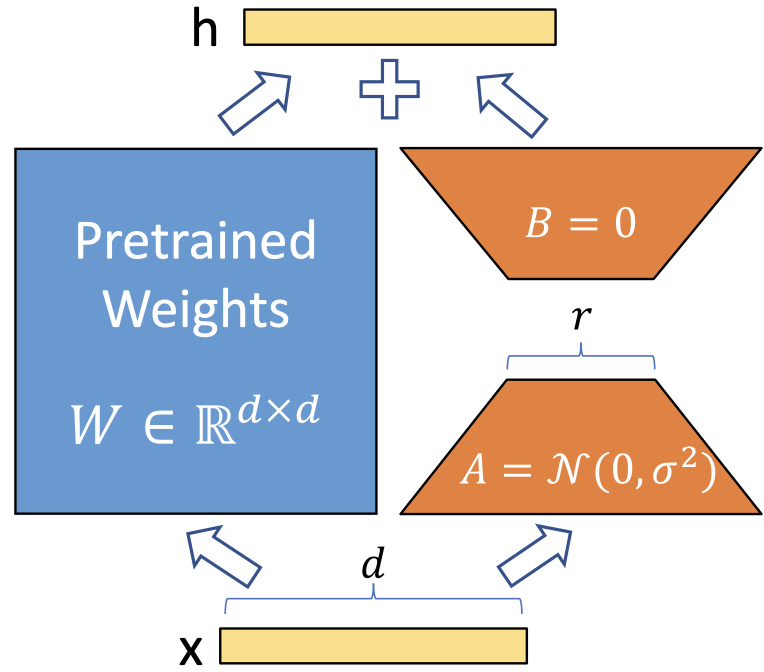

Для реализации Parameter-Efficient Fine-Tuning мы будем пользоваться библиотекой `peft` (семейство huggingface). В ней реализованы многие наиболее удачные способы дообучения моделей. Полный список можно найти [тут](https://github.com/huggingface/peft).

Самый важный параметр этой модели – ранг матриц $A$ и $B$ ($r$). Его увеличение дает больше степеней свободы в настройке добавки $AB$, повышая вместе с этим количество обучаемых параметров.

In [ ]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, inference_mode=False, r=8, lora_dropout=0.1, target_modules=['c_attn']
)

model = Model(tokenizer, num_classes).to(device)
lora_model = get_peft_model(model, peft_config).to(device)
lora_model.print_trainable_parameters()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 296,448 || all params: 124,738,560 || trainable%: 0.2377


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

296448

In [ ]:
optimizer = AdamW(lora_model.parameters(), lr=1e-4)

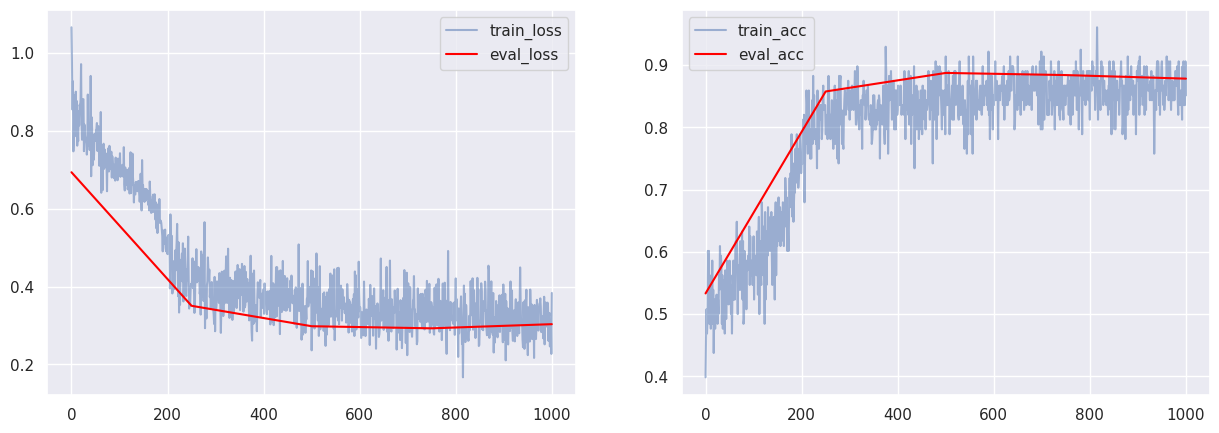

 56%|█████▌    | 218/391 [01:20<01:03,  2.72it/s]

CPU times: user 5min 57s, sys: 2.69 s, total: 6min
Wall time: 6min 6s


In [ ]:
%%time
training_loop_fn(lora_model, optimizer, 1000, 250, train_loader, valid_loader)

In [ ]:
val_loss, val_acc = evaluate(lora_model, valid_loader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')

val loss: 0.30333912700688076
val accuracy: 0.8784403800964355


In [ ]:
torch.save(lora_model.base_model.model.model.score.state_dict(), 'lora_head.pt')

### Prompt Tuning

Prompt Tuning – наиболее архитектурно-зависимый способ дообучения моделей, так как основан на наблюдении о том, что большие языковые модели способны решать задачи в zero-shot и few-shot парадигме (то есть опираясь только на входной промпт и текст, для которого нужно выдать ответ). Для моделей, которые могут работать в таком формате Prompt Tuning предлагает не выбирать промпт руками, а обучить его. Таким образом, этот метод лучше всего будет работать с моделями вида GPT и хуже всего с BERT. Вместе с промптом дополнительно доучивается голова.

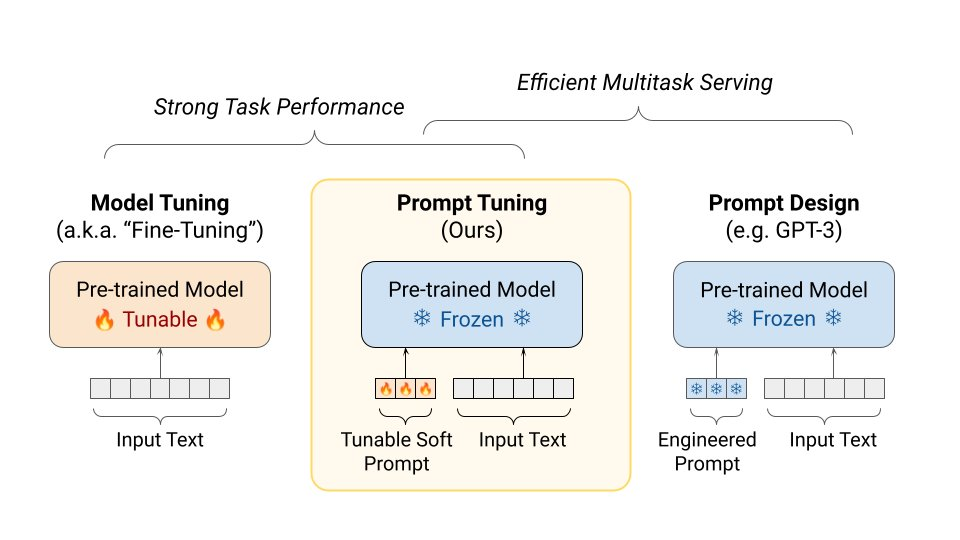<!-- <img src="attachment:60eae4f0-193d-4108-b9c2-8d37e54f791e.png" alt="drawing" width="800"/> -->


При настройке промпта можно варьировать его длину, а так же способ инициализации. Тут работает правило: чем больше датасет для дообучения, тем длинее можно брать промпты. Если датасет маленький, то длиный промпт не сможет обучиться.

In [ ]:
len(tokenizer("Predict if sentiment of this review is positive or negative")['input_ids'])

11

In [ ]:
init = {PromptTuningInit.TEXT: "Predict if sentiment of this review is positive or negative"}

In [ ]:
config = model.config
peft_config = PromptTuningConfig(
    task_type=TaskType.SEQ_CLS, inference_mode=False, num_virtual_tokens=12,
    num_layers=config.n_layer, token_dim=config.n_embd, num_attention_heads=config.n_head,
    prompt_tuning_init=init
)

model = Model(tokenizer, num_classes).to(device)
pt_model = get_peft_model(model, peft_config).to(device)
pt_model.print_trainable_parameters()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 10,752 || all params: 124,452,864 || trainable%: 0.0086


In [ ]:
optimizer = AdamW(pt_model.parameters(), lr=1e-4)

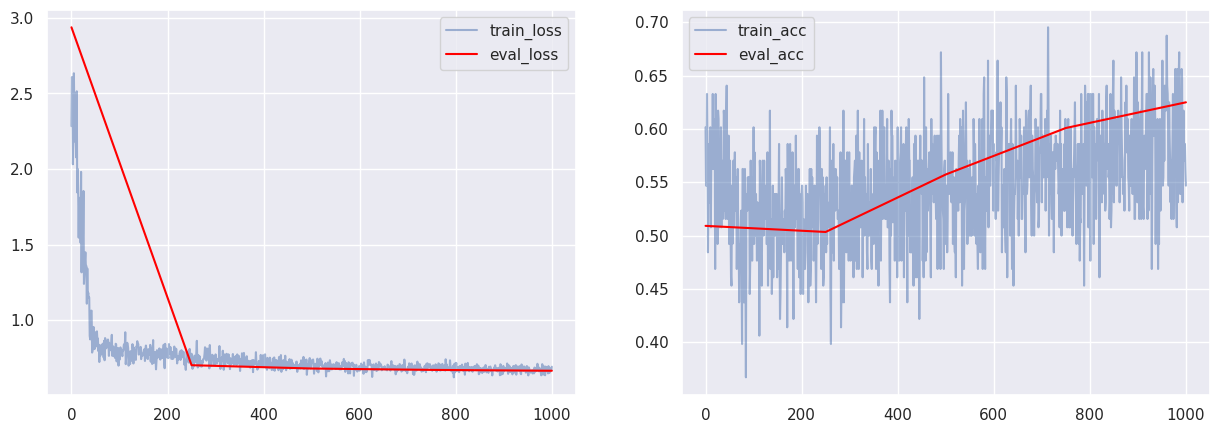

 56%|█████▌    | 218/391 [01:33<01:14,  2.33it/s]

CPU times: user 6min 55s, sys: 3.19 s, total: 6min 59s
Wall time: 7min 5s


In [ ]:
%%time
training_loop_fn(pt_model, optimizer, 1000, 250, train_loader, valid_loader)

In [ ]:
val_loss, val_accuracy = evaluate(pt_model, valid_loader)
print(f'val loss: {val_loss}')
print(f'val acc: {val_accuracy}')

val loss: 0.665939471043578
val acc: 0.625


### LP-FT

In [ ]:
chkpt = torch.load('lora_head.pt')
chkpt.keys()

odict_keys(['original_module.weight', 'modules_to_save.default.weight'])

In [ ]:
model = Model(tokenizer, num_classes).to(device)
model.model.score.load_state_dict({
    'weight': torch.load('lora_head.pt')['modules_to_save.default.weight']
})
optimizer = AdamW(model.parameters(), lr=2e-6)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


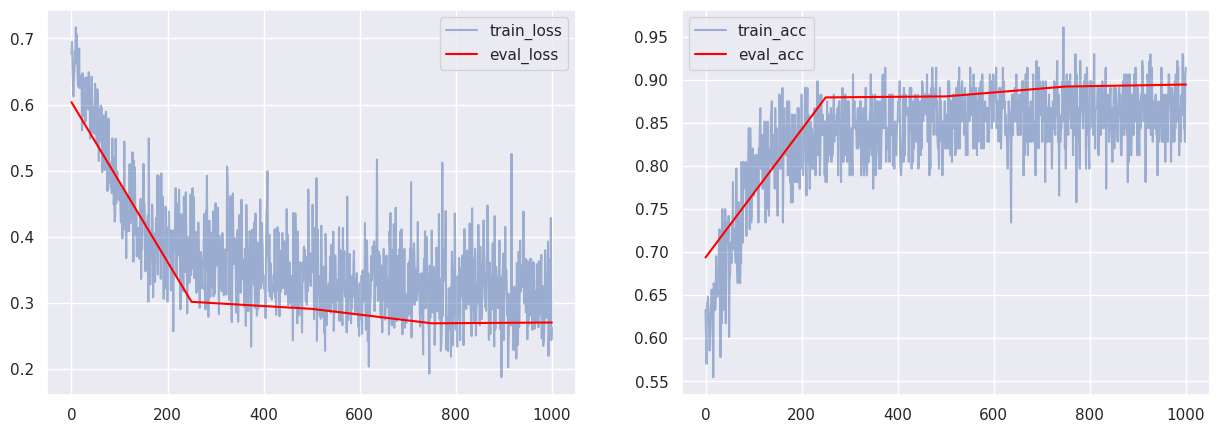

 56%|█████▌    | 218/391 [01:33<01:14,  2.33it/s]

CPU times: user 6min 58s, sys: 3.25 s, total: 7min 1s
Wall time: 7min 7s


In [ ]:
%%time
training_loop_fn(model, optimizer, 1000, 250, train_loader, valid_loader)

In [ ]:
val_loss, val_acc = evaluate(model, valid_loader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')

val loss: 0.270339825831422
val accuracy: 0.89449542760849


### Testing the model

In [ ]:
@torch.no_grad()
def predict(text, target=0):
    tokenized = tokenizer(text, return_tensors='pt')
    for k, v in tokenized.items():
        tokenized[k] = v.to(device)

    logits = model(tokenized['input_ids'], tokenized['attention_mask'], return_dict=False)
    probs = torch.nn.functional.softmax(logits, dim=-1)

    predicted_class_id = int(torch.argmax(logits, dim=-1))
    print(f"text: {text}")
    print(f"target: {target}, pred: {predicted_class_id}")
    print("probs:", probs.cpu().numpy())

In [ ]:
predict("this movie is amaizing", 1)

text: this movie is amaizing
target: 1, pred: 1
probs: [[0.21617264 0.78382736]]


In [ ]:
for i in range(10):
    text = valid_dataset[i]["sentence"]
    label = valid_dataset[i]["label"]
    predict(text, label)
    print()

text: it 's a charming and often affecting journey . 
target: 1, pred: 1
probs: [[0.00224956 0.99775046]]

text: unflinchingly bleak and desperate 
target: 0, pred: 0
probs: [[0.89577955 0.10422049]]

text: allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
target: 1, pred: 1
probs: [[0.02555279 0.97444725]]

text: the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
target: 1, pred: 1
probs: [[0.01579455 0.9842054 ]]

text: it 's slow -- very , very slow . 
target: 0, pred: 0
probs: [[0.9552564  0.04474357]]

text: although laced with humor and a few fanciful touches , the film is a refreshingly serious look at young women . 
target: 1, pred: 1
probs: [[0.01125399 0.988746  ]]

text: a sometimes tedious film . 
target: 0, pred: 0
probs: [[0.9609606  0.03903938]]

text: or doing last year 's taxes with your ex-wife . 
target: 0, pred: 0
probs: [[0.83872426 0.1612757

In [ ]:
del model
del tokenizer
torch.cuda.empty_cache()
gc.collect()

In [ ]:
torch.cuda.empty_cache()
gc.collect()

# Zero-shot

Теперь давайте соберем Zero-shot подход. Для этого мы используем функцию потерь модели.

Модели на основе GPT используют покомпонентную (per-token) кросс-энтропийную функцию потерь, которая из-за one-hot кодирования токенов сводится к отрицательному логарифму вероятности. **Идея заключается в том, чтобы выбрать целевую метку, связанную с тем промптом, для которого сумма отрицательных логарифмов вероятностей его токенов минимальна.**

Эта идея работает, потому что языковая модель обучена присваивать более высокую вероятность тем продолжениям текста, которые лучше согласуются с контекстом, а класс-метка в zero-shot выступает именно как такое «продолжение».

Модель возьмем ruGPT. ruGPT-3 — семейство русскоязычных языковых моделей на основе архитектуры Transformer, разработанное и развиваемое командой Сбер (SberDevices/Sber AI) как адаптация идей GPT-3 от OpenAI под русский язык.

* Год выпуска: первая версия ruGPT-3 появилась в декабре 2020 г. и развивалась в последующие годы (рост числа параметров и новые версии).

* Число параметров: базовые версии были с разным масштабом (например, от ~760 млн до ~1,3 млрд)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("ai-forever/rugpt3large_based_on_gpt2")

model = AutoModelForCausalLM.from_pretrained("ai-forever/rugpt3large_based_on_gpt2")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

In [ ]:
num_params = sum(p.numel() for p in model.parameters())
print(f"{num_params:,}")
print(f"{num_params/1e6:.1f}M")
print(f"{num_params/1e9:.2f}B")

760,300,032
760.3M
0.76B


In [ ]:
model.cuda()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1536)
    (wpe): Embedding(2048, 1536)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=4608, nx=1536)
          (c_proj): Conv1D(nf=1536, nx=1536)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=6144, nx=1536)
          (c_proj): Conv1D(nf=1536, nx=6144)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1536, out_features=50257, bias=False)
)

In [ ]:
import math
def get_loss_num(text):
    # Tokenize the input text and move it to the specified device
    inputs = tokenizer(text, return_tensors="pt").to(device)

    # Shift the inputs to create labels for the next-token prediction task
    labels = inputs["input_ids"].clone() # В задаче language modeling метки — это те же самые токены

    # Move labels to the correct device if you're using GPU
    labels = labels.to(device)

    # Calculate loss
    outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    return loss.item()

### Задача: анализ тональности твитов

Сегодня мы решим задачу анализа тональности. Начнём с нескольких простых (toy) примеров и попробуем придумать такие промпты, которые позволяют различать позитивные и негативные тексты.

**Пример позитивного промпта**

In [ ]:
text = 'жизнь отличная'
get_loss_num('Позитивный твит: ' + text)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


6.202009201049805

**Negative prompt example**

In [ ]:
get_loss_num('Негативный твит: ' + text)

7.3455810546875

Добавим смайлики

In [ ]:
print(get_loss_num('Позитивный твит: ' + text + ')'))
print(get_loss_num('Негативный твит: ' + text + '('))

5.80208158493042
7.4813666343688965


Теперь мы реализуем функцию, которая выбирает метку, дающую наименьшее значение функции потерь.

In [ ]:
def predict_zero_shot(text, pos = 'Positive text: {})', neg = 'Negative text: {}('):
  pos_loss = get_loss_num(pos.format(text))
  neg_loss = get_loss_num(neg.format(text))
  if pos_loss < neg_loss:
    return 'positive'
  return 'negative'

predict_zero_shot(text)

'positive'

Применим этот подход для классификации тональности твитов

In [ ]:
!wget -O twitter_short.csv https://drive.usercontent.google.com/download?id=17qSrjy5NyknCfhs1kqGwHcHgml9UzpvS&export=download&authuser=0&confirm=t&uuid=cb32846f-bc96-4eb0-9e29-57d27a89e369&at=AN_67v2rr2Fh_KVc0V-EDJQ7bufm:1729946024386

--2026-01-21 16:27:36--  https://drive.usercontent.google.com/download?id=17qSrjy5NyknCfhs1kqGwHcHgml9UzpvS
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.117.132, 2607:f8b0:400e:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.117.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14363 (14K) [application/octet-stream]
Saving to: ‘twitter_short.csv’

twitter_short.csv   100%[===================>]  14.03K  --.-KB/s    in 0s      

2026-01-21 16:27:38 (78.4 MB/s) - ‘twitter_short.csv’ saved [14363/14363]



In [ ]:
import pandas as pd
df = pd.read_csv('twitter_short.csv', index_col = 0)
df.head()

,text,label
0,на работе был полный пиддес :| и так каждое за...,negative
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",negative
2,@elina_4post как говорят обещаного три года жд...,negative
3,"Желаю хорошего полёта и удачной посадки,я буду...",negative
4,"Обновил за каким-то лешим surf, теперь не рабо...",negative


In [ ]:
df.tail()

,text,label
95,"Встречайте, мои супер одногруппницы, будущие и...",positive
96,"все,я вас покидаю,результаты гляну вечером)#би...",positive
97,RT @Dasha_crazy_69: @DashkaTeddy дыы))) но кто...,positive
98,Почти приехали в родное селенье!) @ москва-рига,positive
99,На*уй ваши Канары и Мальдивы ! Тут новая тема ...,positive


In [ ]:
df.label.value_counts()

,count
label,
negative,50
positive,50


In [ ]:
from sklearn.metrics import accuracy_score

df['preds'] = df.text.apply(predict_zero_shot)
accuracy_score(df.label, df.preds)

0.63

In [ ]:
from sklearn.metrics import f1_score

def encode_label(x):
  if x == 'negative':
    return 0
  return 1

f1_score(df.label.apply(encode_label), df.preds.apply(encode_label))

0.7299270072992701